# Classificação de Dígitos Manuscritos com Machine Learning

## Objetivo

Desenvolver e comparar modelos de classificação capazes de reconhecer dígitos manuscritos do dataset **MNIST**. A análise considera o desempenho preditivo, o custo computacional e a robustez dos modelos em diferentes cenários.

## Etapas de desenvolvimento

### 1. Carregamento e análise exploratória dos dados

- Carregar o dataset MNIST.
- Verificar o formato dos dados, as classes e a quantidade de amostras.
- Avaliar o balanceamento entre as classes.
- Visualizar exemplos dos dígitos.

### 2. Preparação dos dados

- Separar os dados em conjuntos de treino, validação e teste.
- Manter a proporção das classes durante a divisão.
- Normalizar os valores dos pixels para o intervalo entre 0 e 1.

### 3. Treinamento dos modelos

Treinar e comparar os seguintes modelos:

- Random Forest;
- Regressão Logística;
- Rede Neural MLP.

Também serão definidos e ajustados hiperparâmetros para buscar melhores resultados.

### 4. Avaliação dos modelos

Comparar os modelos utilizando:

- Acurácia;
- Precisão;
- Recall;
- F1-Score;
- Matrizes de confusão;
- Tempo de treinamento.

### 5. Teste de robustez

- Verificar o comportamento dos modelos quando determinados dígitos não aparecem no treinamento.
- Testar o modelo selecionado com imagens de dígitos escritos à mão.
- Processar as imagens externas utilizando OpenCV.

## Resultado esperado

Ao final, selecionar o modelo com o melhor equilíbrio entre desempenho, tempo de treinamento e capacidade de generalização.

Fase 1: Carregamento e Análise Exploratória de Dados (EDA)

Dataset baixado com sucesso!

=== DIMENSIONALIDADE DOS MATRIZES ===
Matriz de Características (X): (70000, 784) (Imagens x Pixels)
Matriz de Rótulos (y): (70000,)



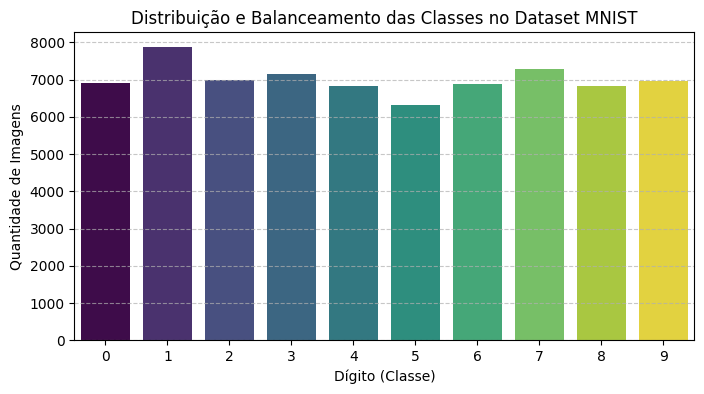

=== GRADE VISUAL: EXEMPLOS DE DÍGITOS ===


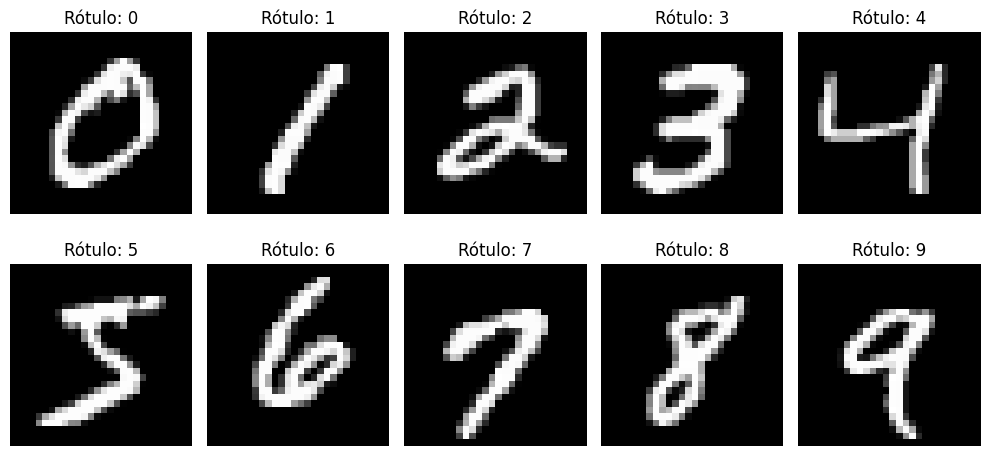

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

mnist = fetch_openml(
    'mnist_784',
    version=1,
    as_frame=False,
    parser='auto',
    data_home='./data'
 )

print("Dataset baixado com sucesso!")

# Separando recursos (X) e rótulos (y)
X, y = mnist["data"], mnist["target"]
y = y.astype(np.uint8)

# 1. EXIBIR DIMENSIONALIDADE
print("\n=== DIMENSIONALIDADE DOS MATRIZES ===")
print(f"Matriz de Características (X): {X.shape} (Imagens x Pixels)")
print(f"Matriz de Rótulos (y): {y.shape}\n")

# 2. COMPROVAR O BALANCEAMENTO DAS CLASSES
classes, contagens = np.unique(y, return_counts=True)
plt.figure(figsize=(8, 4))
sns.barplot(
    x=classes,
    y=contagens,
    hue=classes,
    palette="viridis",
    legend=False
)
plt.title("Distribuição e Balanceamento das Classes no Dataset MNIST")
plt.xlabel("Dígito (Classe)")
plt.ylabel("Quantidade de Imagens")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 3. GERAR GRADE VISUAL (Mínimo 2x5)
print("=== GRADE VISUAL: EXEMPLOS DE DÍGITOS ===")
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.ravel()

for i in range(10):
    indice = np.where(y == i)
    imagem_digito = X[indice][0].reshape(28, 28) # Pega o primeiro exemplo de cada dígito
    axes[i].imshow(imagem_digito, cmap="gray")
    axes[i].set_title(f"Rótulo: {i}", fontsize=12)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

Fase 2: Preparação dos Dados

A normalização dos pixels para a escala [0, 1] é fundamental para algoritimos de Machine Learning porque garante que todos os recursos (features) tenham o mesmo peso inicial. Para modelos lineares e baseados em distâncias métricas, dados não normalizados causam instabilidade no gradiente, fazendo com que o modelo demore muito mais para convergir (encontrar o resultado ideal) ou at´e mesmo falhe em convergir.

In [2]:
# Normalizando os valores dos pixels para o intervalo [0, 1]
x_scaled = X / 255.0  

X_train_val, X_test, y_train_val, y_test = train_test_split(
    x_scaled, 
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, 
    y_train_val,
    test_size=0.125,
    stratify=y_train_val,
    random_state=42
)

display("\n=== DIVISÃO DO DATASET ===")
display(f"Treinamento: {X_train.shape[0]} amostras")
display(f"Validação: {X_val.shape[0]} amostras")
display(f"Teste: {X_test.shape[0]} amostras")

'\n=== DIVISÃO DO DATASET ==='

'Treinamento: 49000 amostras'

'Validação: 7000 amostras'

'Teste: 14000 amostras'

Fase 3: Treinamento dos Modelos

1 = MODELO RANDOM FOREST

In [3]:
modelo_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

modelo_rf.fit(X_train, y_train)

predicoes = modelo_rf.predict(X_test)

report_dict = classification_report(y_test, predicoes, output_dict=True)

df_metrics = pd.DataFrame(report_dict).transpose()

df_metrics.round(4)

,precision,recall,f1-score,support
0,0.9624,0.9833,0.9728,1381.0000
1,0.9643,0.9771,0.9707,1575.0000
2,0.9479,0.9363,0.9421,1398.0000
3,0.9385,0.9300,0.9342,1428.0000
4,0.9528,0.9326,0.9426,1365.0000
5,0.9579,0.9192,0.9382,1263.0000
6,0.9557,0.9731,0.9643,1375.0000
7,0.9488,0.9404,0.9446,1459.0000
8,0.9251,0.9231,0.9241,1365.0000
9,0.8904,0.9224,0.9061,1391.0000


2 = MODELO KNN

In [4]:
modelo_knn = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance'
)

modelo_knn.fit(X_train, y_train)

predicoes_knn = modelo_knn.predict(X_test)

report_dict_knn = classification_report(y_test, predicoes_knn, output_dict=True)

df_metrics_knn = pd.DataFrame(report_dict_knn).transpose()

df_metrics_knn.round(4)

,precision,recall,f1-score,support
0,0.9745,0.9949,0.9846,1381.0000
1,0.9543,0.9937,0.9736,1575.0000
2,0.9889,0.9528,0.9705,1398.0000
3,0.9706,0.9727,0.9717,1428.0000
4,0.9864,0.9568,0.9714,1365.0000
5,0.9613,0.9628,0.9620,1263.0000
6,0.9741,0.9862,0.9801,1375.0000
7,0.9634,0.9753,0.9693,1459.0000
8,0.9869,0.9377,0.9617,1365.0000
9,0.9485,0.9662,0.9573,1391.0000


3 = MODELO SVM

In [5]:
modelo_svm = SVC(
    C=1.0,
    kernel='rbf',
    gamma='scale',
    random_state=42
)

modelo_svm.fit(X_train, y_train)

predicoes_svm = modelo_svm.predict(X_test)

report_dict_svm = classification_report(y_test, predicoes_svm, output_dict=True)

df_metrics_svm = pd.DataFrame(report_dict_svm).transpose()

df_metrics_svm.round(4)

,precision,recall,f1-score,support
0,0.9786,0.9949,0.9867,1381.0000
1,0.9848,0.9886,0.9867,1575.0000
2,0.9764,0.9785,0.9775,1398.0000
3,0.9774,0.9685,0.9729,1428.0000
4,0.9750,0.9714,0.9732,1365.0000
5,0.9808,0.9723,0.9765,1263.0000
6,0.9833,0.9847,0.9840,1375.0000
7,0.9754,0.9767,0.9760,1459.0000
8,0.9744,0.9751,0.9747,1365.0000
9,0.9675,0.9619,0.9647,1391.0000


4 = REDE NEURAL PERCEPTRON

In [6]:
modelo_mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    max_iter=200,
    random_state=42
)

modelo_mlp.fit(X_train, y_train)

predicoes_mlp = modelo_mlp.predict(X_test)

report_dict_mlp = classification_report(y_test, predicoes_mlp, output_dict=True)

df_metrics_mlp = pd.DataFrame(report_dict_mlp).transpose()

df_metrics_mlp.round(4)

,precision,recall,f1-score,support
0,0.9779,0.9949,0.9864,1381.0000
1,0.9836,0.9892,0.9864,1575.0000
2,0.9806,0.9764,0.9785,1398.0000
3,0.9781,0.9713,0.9747,1428.0000
4,0.9744,0.9744,0.9744,1365.0000
5,0.9730,0.9715,0.9723,1263.0000
6,0.9891,0.9855,0.9872,1375.0000
7,0.9714,0.9760,0.9737,1459.0000
8,0.9777,0.9641,0.9709,1365.0000
9,0.9627,0.9641,0.9634,1391.0000
